In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('D:\S t u d y\zGraduation Project\CASIA2'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00001.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00002.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00003.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00004.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00005.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00006.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00007.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00008.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00009.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00010.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00011.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00012.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00013.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00014.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00015.jpg
D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00016.jpg
D:\S t u d y\zGraduation Project\CASIA2\

D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CND_M_N_ani00018_sec00096_00138.tif
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CND_M_N_art00076_art00077_10289.tif
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CND_M_N_art00077_art00076_10290.tif
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CND_S_N_ani00073_ani00068_00193.tif
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CND_S_N_ind00078_ind00077_00476.tif
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CND_S_N_txt00028_txt00006_10848.jpg
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CNN_M_B_nat00056_nat00099_11105.jpg
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CNN_M_B_nat10139_nat00059_11949.jpg
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CNN_M_B_nat10139_nat00097_11948.jpg
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CNN_M_N_ani00023_ani00024_10205.tif
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CNN_M_N_ani00052_ani00054_11130.jpg
D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CNN_M_N_ani00057_ani00055_11

In [2]:
import os
import sys
import os
from PIL import Image,ImageChops,ImageEnhance
def ela_image(path, quality=98):
    temp_filename = 'temp_file_name.jpg'
    ela_filename = 'temp_ela.png' 
    image = Image.open(path).convert('RGB')
    image.save(temp_filename, 'JPEG', quality = quality)
    temp_image = Image.open(temp_filename)
    ela_image = ImageChops.difference(image, temp_image)
    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff 
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)  
    return ela_image

In [3]:
Real_image_path='D:\S t u d y\zGraduation Project\CASIA2\Au\Au_ani_00003.jpg'
Fake_image_path1='D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_D_CND_M_N_art00077_art00076_10290.tif'
Fake_image_path2='D:\S t u d y\zGraduation Project\CASIA2\Tp\Tp_S_NRN_S_N_txt00071_txt00071_11300.jpg'

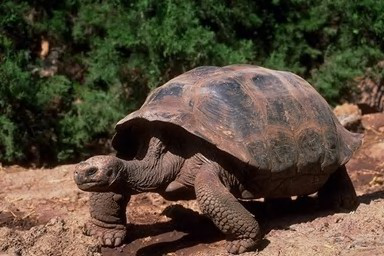

In [4]:
Image.open(Real_image_path)

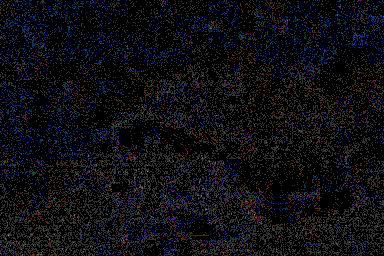

In [5]:
ela_image(Real_image_path)

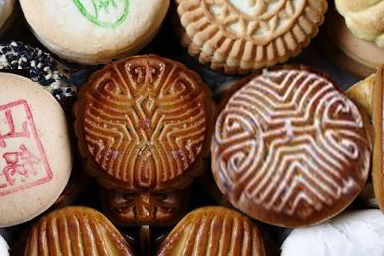

In [6]:
Image.open(Fake_image_path1)

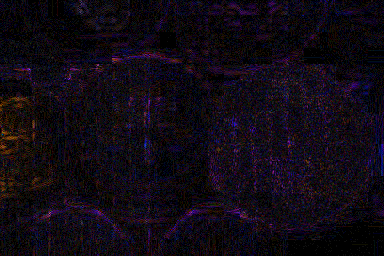

In [7]:
ela_image(Fake_image_path1)

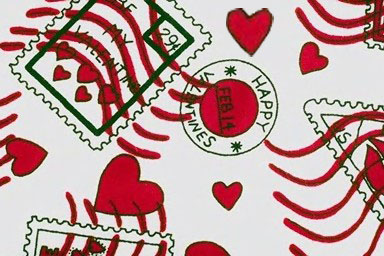

In [8]:
Image.open(Fake_image_path2)

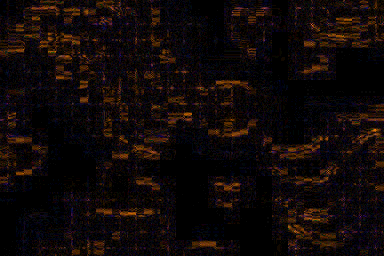

In [9]:
ela_image(Fake_image_path2)

In [10]:
image_size=(128,128)

In [11]:
def preprocessing(image_path):
    return np.array(ela_image(image_path).resize(image_size)).flatten()/255

In [12]:
import numpy as np
preprocessing(Fake_image_path2)

array([0.        , 0.        , 0.03137255, ..., 0.03529412, 0.03137255,
       0.03137255])

In [13]:
X=[]
Y=[]

In [14]:
import random
path = 'D:\S t u d y\zGraduation Project\CASIA2\Au'
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('jpg') or filename.endswith('tif'):
            full_path = os.path.join(dirname, filename)
            X.append(preprocessing(full_path))
            Y.append(1)
random.shuffle(X)

print(len(X), len(Y))

7354 7354


In [15]:
len(X)

7354

In [16]:
path = 'D:\S t u d y\zGraduation Project\CASIA2\Tp'
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('jpg') or filename.endswith('tif'):
            full_path = os.path.join(dirname, filename)
            X.append(preprocessing(full_path))
            Y.append(0)
print(len(X), len(Y))

12477 12477


In [17]:
from keras.utils.np_utils import to_categorical
X = np.array(X)
Y = to_categorical(Y, 2)
X = X.reshape(-1, 128, 128, 3)

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_val,Y_train,Y_val=train_test_split(X,Y,test_size=0.2,random_state=10)

print(len(X_train), len(Y_train))
print(len(X_val), len(Y_val))

9981 9981
2496 2496


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from keras.utils.np_utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.layers import BatchNormalization
from keras.layers.pooling import MaxPooling2D, AveragePooling2D
from tensorflow.keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping
def CNN():
    model = Sequential()
    model.add(Conv2D(filters=128,kernel_size=(5,5),activation='relu',input_shape=(128,128,3)))
    model.add(AveragePooling2D(pool_size=(2,2)))
    model.add(Conv2D(filters=256,kernel_size=(5,5),activation='relu'))
    model.add(AveragePooling2D(pool_size=(2,2)))
    model.add(Flatten())
    model.add(Dense(units=64,activation='relu'))
    model.add(Dropout(0.5))
    model.add(BatchNormalization())
    model.add(Dense(units=16,activation='relu'))
    model.add(Dropout(0.5))
    model.add(BatchNormalization())
    model.add(Dense(units=2,activation='softmax'))
    return model

In [20]:
model1=CNN()
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 124, 124, 128)     9728      
                                                                 
 average_pooling2d (AverageP  (None, 62, 62, 128)      0         
 ooling2D)                                                       
                                                                 
 conv2d_1 (Conv2D)           (None, 58, 58, 256)       819456    
                                                                 
 average_pooling2d_1 (Averag  (None, 29, 29, 256)      0         
 ePooling2D)                                                     
                                                                 
 flatten (Flatten)           (None, 215296)            0         
                                                                 
 dense (Dense)               (None, 64)                1

In [21]:
epochs = 30
batch_size = 64
init_lr = 1e-4
optimizer = Adam(learning_rate = init_lr, decay = init_lr/epochs)
early_stopping = EarlyStopping(monitor='val_accuracy',
                                patience=5,
                                verbose=1 ,
                                min_delta=0,
                                mode='max')
model1.compile(optimizer = optimizer, loss = 'BinaryCrossentropy', metrics = ['accuracy'])

In [23]:
del Y

In [24]:
del X

In [25]:
history = model1.fit(X_train, Y_train, validation_data = (X_val, Y_val), epochs= 30, batch_size= 64, verbose = 1, callbacks = early_stopping)

Epoch 1/30
156/156 [==============================] - 805s 5s/step - loss: 0.5982 - accuracy: 0.7520 - val_loss: 0.6868 - val_accuracy: 0.4099
Epoch 2/30
156/156 [==============================] - 693s 4s/step - loss: 0.4846 - accuracy: 0.8468 - val_loss: 0.6058 - val_accuracy: 0.9135
Epoch 3/30
156/156 [==============================] - 667s 4s/step - loss: 0.4386 - accuracy: 0.8722 - val_loss: 0.4826 - val_accuracy: 0.9207
Epoch 4/30
156/156 [==============================] - 745s 5s/step - loss: 0.4048 - accuracy: 0.8847 - val_loss: 0.4122 - val_accuracy: 0.9123
Epoch 5/30
156/156 [==============================] - 682s 4s/step - loss: 0.3739 - accuracy: 0.8961 - val_loss: 0.3132 - val_accuracy: 0.9247
Epoch 6/30
156/156 [==============================] - 690s 4s/step - loss: 0.3460 - accuracy: 0.9051 - val_loss: 0.2736 - val_accuracy: 0.9275
Epoch 7/30
156/156 [==============================] - 682s 4s/step - loss: 0.3196 - accuracy: 0.9133 - val_loss: 0.2613 - val_accuracy: 0.9263

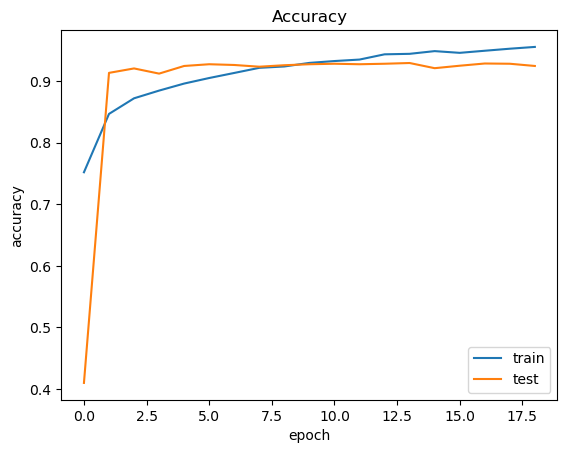

In [26]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'])
plt.show()

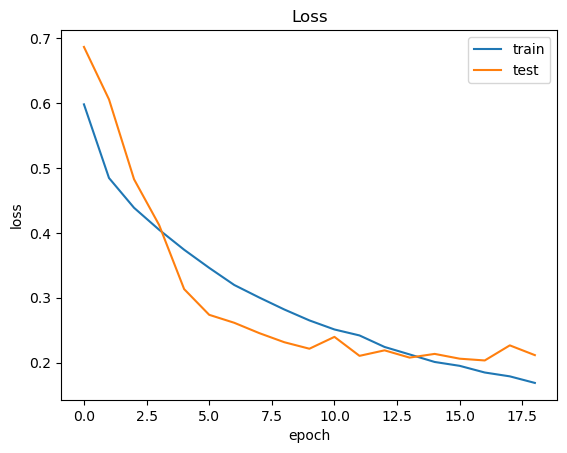

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'])
plt.show()

In [28]:
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
   
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


78/78 [==============================] - 41s 527ms/step


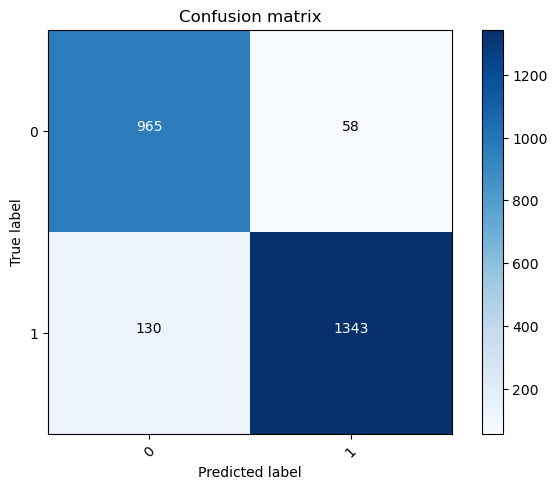

In [29]:
Y_pred = model1.predict(X_val)
Y_pred_classes = np.argmax(Y_pred,axis = 1) 
Y_true = np.argmax(Y_val,axis = 1) 
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 
plot_confusion_matrix(confusion_mtx, classes = range(2))

In [30]:
model1.save('GRADUATION PRJECT.h5')